In [1]:
# Import Required Libraries 
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
# Machine Learning Libraries 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, mean_squared_error

# Models 
from sklearn.linear_model import LinearRegression, LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.svm import SVC 
from sklearn.neighbors import KNeighborsClassifier


In [2]:
# Load Dataset 
df = pd.read_csv("winequality-red.csv") 

In [3]:
# DATA EXPLORATION
print("First 5 Rows of Dataset") 
print(df.head()) 

print("\nDataset Shape") 
print(df.shape)

print("\nMissing Values") 
print(df.isnull().sum())

print("\nStatistical Summary") 
print(df.describe())

print("\nMedian Values") 
print(df.median())

First 5 Rows of Dataset
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        

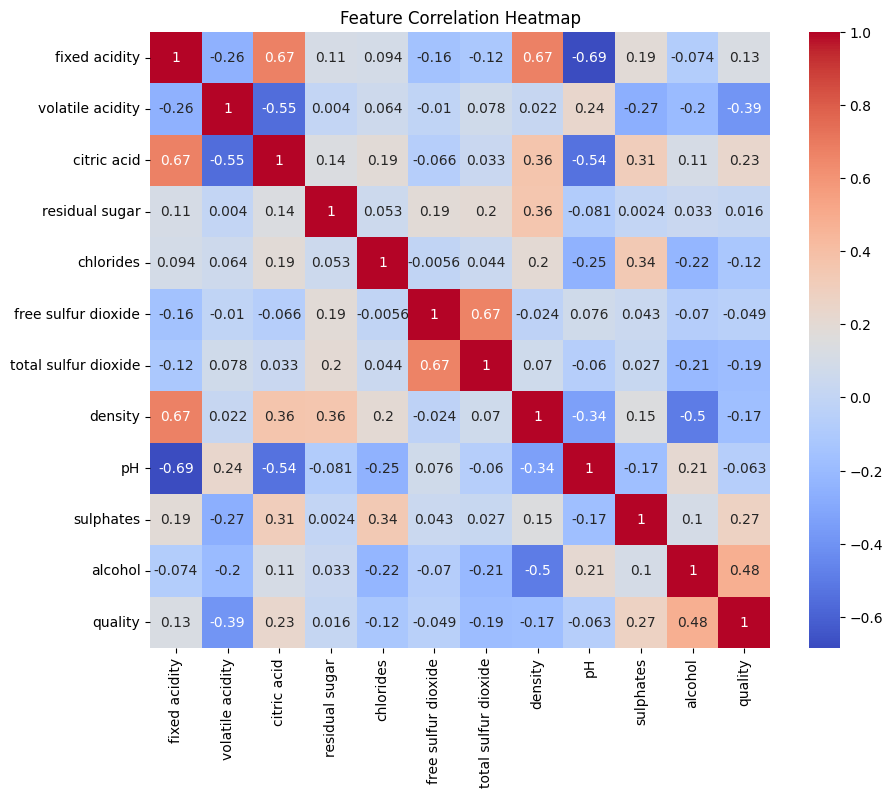

In [4]:
# Correlation Visualization 

plt.figure(figsize=(10,8)) 
sns.heatmap(df.corr(), annot=True, cmap="coolwarm") 
plt.title("Feature Correlation Heatmap") 
plt.show()

In [5]:
# 3. DATA PREPROCESSING 
# Convert quality into classification (good / bad)

df['quality_label'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0) 

In [6]:
# Features and Target 
X = df.drop(['quality','quality_label'], axis=1) 
y = df['quality_label'] 

In [7]:
# Feature Scaling 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X)

In [8]:
# Train Test Split 
X_train, X_test, y_train, y_test = train_test_split( 
X_scaled, y, test_size=0.3, random_state=42)

In [9]:
# 4. MODEL BUILDING 

models = { 
"Linear Regression": LinearRegression(), 
"Logistic Regression": LogisticRegression(), 
"Decision Tree": DecisionTreeClassifier(), 
"Random Forest": RandomForestClassifier(), 
"SVM": SVC(), 
"KNN": KNeighborsClassifier() 
}
results = [] 
 
for name, model in models.items(): 
 
    model.fit(X_train, y_train) 
 
    predictions = model.predict(X_test) 

In [10]:
 # Convert regression output to class 
if name == "Linear Regression": 
        predictions = np.round(predictions) 
 
acc = accuracy_score(y_test, predictions) 
prec = precision_score(y_test, predictions) 
rec = recall_score(y_test, predictions) 
f1 = f1_score(y_test, predictions) 
mse = mean_squared_error(y_test, predictions) 
 
results.append([name, acc, prec, rec, f1, mse])
print("\nModel:", name) 
print("Accuracy:", acc) 
print("Precision:", prec) 
print("Recall:", rec) 
print("F1 Score:", f1) 
print("MSE:", mse)
print("\nConfusion Matrix") 
print(confusion_matrix(y_test, predictions)) 



Model: KNN
Accuracy: 0.8914405010438413
Precision: 0.5952380952380952
Recall: 0.4166666666666667
F1 Score: 0.49019607843137253
MSE: 0.10855949895615867

Confusion Matrix
[[402  17]
 [ 35  25]]


In [11]:
# 5. MODEL COMPARISON 

results_df = pd.DataFrame(results, columns=[ 
"Model", "Accuracy", "Precision", "Recall", "F1 Score", "MSE" 
]) 
print("\nModel Performance Comparison") 
print(results_df)


Model Performance Comparison
  Model  Accuracy  Precision    Recall  F1 Score       MSE
0   KNN  0.891441   0.595238  0.416667  0.490196  0.108559


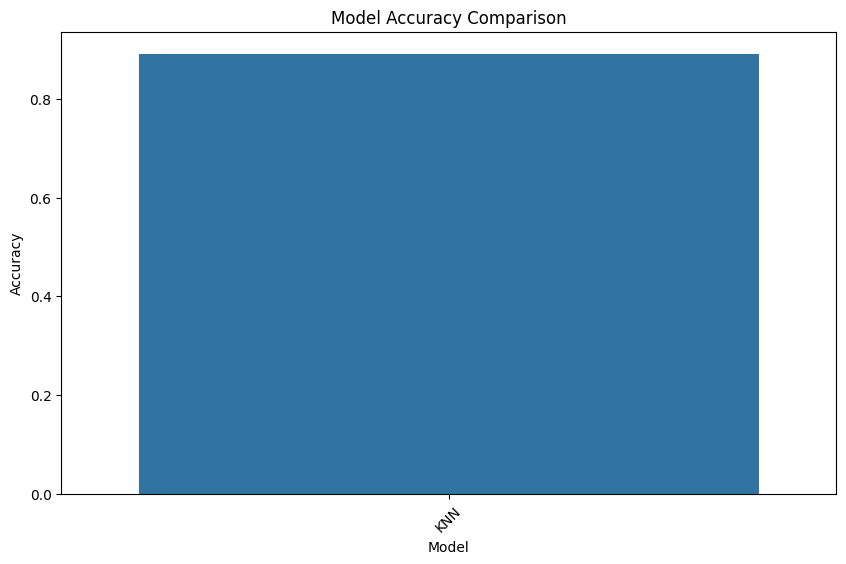

In [12]:
# Visualization of Model Accuracy 

plt.figure(figsize=(10,6)) 
sns.barplot(x="Model", y="Accuracy", data=results_df) 
plt.title("Model Accuracy Comparison") 
plt.xticks(rotation=45) 
plt.show()

In [13]:
# Best Model Identification 
 
best_model = results_df.loc[results_df['Accuracy'].idxmax()] 
print("\nBest Performing Model:") 
print(best_model)


Best Performing Model:
Model             KNN
Accuracy     0.891441
Precision    0.595238
Recall       0.416667
F1 Score     0.490196
MSE          0.108559
Name: 0, dtype: object


In [14]:
import pickle
pickel.dump(svm,open('Wine Quality Prediction',"wb"))

NameError: name 'pickel' is not defined